In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    top_k_accuracy_score
)

In [2]:
recommendation_system = joblib.load(
    "personalized_recommendation_system.pkl"
)

recommendation_model = recommendation_system["model"]
patient_features = recommendation_system["patient_features"]
model_classes = np.array(
    recommendation_system["model_classes"]
)

condition_class_prior = recommendation_system[
    "condition_class_prior"
]

model_weight = recommendation_system["model_weight"]

condition_history_weight = recommendation_system[
    "condition_history_weight"
]

print("Recommendation system loaded.")
print("Number of classes:", len(model_classes))
print("Model weight:", model_weight)
print(
    "Condition-history weight:",
    condition_history_weight
)

Recommendation system loaded.
Number of classes: 12
Model weight: 0.8
Condition-history weight: 0.2


In [3]:
evaluation_df = pd.read_excel(
    "clinical_feature_engineered_data.xlsx",
    sheet_name="Feature_Engineered_Data"
)

evaluation_df.columns = (
    evaluation_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("Dataset shape:", evaluation_df.shape)
evaluation_df.head()

Dataset shape: (500, 31)


,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,...,bp_age_interaction,allergy_recorded_flag,family_history_flag,adherence_score,glucose_mg_dl_dataset_zscore,systolic_bp_mmhg_dataset_zscore,diastolic_bp_mmhg_dataset_zscore,cholesterol_mg_dl_dataset_zscore,heart_rate_bpm_dataset_zscore,measurement_deviation_score
0,SYN-0001,28,Female,Seasonal Allergy,97,132,85,214,73,None recorded,...,3696,0,0,2,-0.324226,0.254356,0.339338,0.424061,-0.315852,0.331566
1,SYN-0002,80,Female,Acid Reflux,80,123,79,189,59,None recorded,...,9840,0,1,1,-0.809337,-0.237734,-0.210049,-0.216205,-1.546215,0.603908
2,SYN-0003,36,Female,Asthma,86,121,66,192,82,None recorded,...,4356,0,0,1,-0.638121,-0.347087,-1.400387,-0.139373,0.475096,0.600013
3,SYN-0004,21,Male,High Cholesterol,103,120,69,278,85,None recorded,...,2520,0,1,2,-0.153010,-0.401764,-1.125693,2.063142,0.738745,0.896471
4,SYN-0005,58,Male,High Cholesterol,79,111,76,244,64,None recorded,...,6438,0,1,2,-0.837873,-0.893854,-0.484742,1.192380,-1.106799,0.903130


In [4]:
target_column = "historical_medication_class"

X = evaluation_df[
    patient_features
].copy()

y = evaluation_df[
    target_column
].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Evaluation records:", len(X_test))
print("Evaluation classes:", y_test.nunique())

Evaluation records: 100
Evaluation classes: 12


In [5]:
base_scores = recommendation_model.predict_proba(
    X_test
)

print("Base score matrix:", base_scores.shape)

Base score matrix: (100, 12)


In [6]:
condition_scores = []

uniform_scores = np.ones(
    len(model_classes)
) / len(model_classes)

for condition in X_test["condition"]:

    if condition in condition_class_prior.index:

        prior = condition_class_prior.loc[
            condition,
            model_classes
        ].values.astype(float)

    else:
        prior = uniform_scores.copy()

    condition_scores.append(prior)

condition_scores = np.array(
    condition_scores
)

print(
    "Condition score matrix:",
    condition_scores.shape
)

Condition score matrix: (100, 12)


In [7]:
hybrid_scores = (
    model_weight * base_scores +
    condition_history_weight * condition_scores
)

hybrid_scores = (
    hybrid_scores /
    hybrid_scores.sum(axis=1, keepdims=True)
)

print("Hybrid ranking scores created.")

Hybrid ranking scores created.


In [8]:
ranked_indices = np.argsort(
    hybrid_scores,
    axis=1
)[:, ::-1]

ranked_classes = model_classes[
    ranked_indices
]

ranked_probabilities = np.take_along_axis(
    hybrid_scores,
    ranked_indices,
    axis=1
)

print("Ranked classes shape:", ranked_classes.shape)

Ranked classes shape: (100, 12)


In [9]:
ranking_results = pd.DataFrame({
    "patient_id": evaluation_df.loc[
        X_test.index,
        "patient_id"
    ].values,
    "condition": X_test["condition"].values,
    "recorded_allergy":
        X_test["recorded_allergy"].values,
    "actual_historical_class": y_test.values
})

for rank in range(3):

    ranking_results[
        f"rank_{rank + 1}_class"
    ] = ranked_classes[:, rank]

    ranking_results[
        f"rank_{rank + 1}_score"
    ] = ranked_probabilities[
        :, rank
    ].round(4)

ranking_results.head(10)

,patient_id,condition,recorded_allergy,actual_historical_class,rank_1_class,rank_1_score,rank_2_class,rank_2_score,rank_3_class,rank_3_score
0,SYN-0049,Asthma,None recorded,Controller inhaler class,Controller inhaler class,0.7134,Bronchodilator class,0.2502,Antihistamine class B,0.0085
1,SYN-0135,Type 2 Diabetes,None recorded,Antidiabetic class A,Antidiabetic class B,0.5832,Antidiabetic class A,0.4110,Bronchodilator class,0.0015
2,SYN-0094,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5792,Lipid-lowering class B,0.4040,Antihypertensive class A,0.0043
3,SYN-0131,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5383,Lipid-lowering class B,0.4519,Antihistamine class B,0.0021
4,SYN-0467,Seasonal Allergy,None recorded,Antihistamine class B,Antihistamine class A,0.5194,Antihistamine class B,0.3572,Lipid-lowering class A,0.0326
5,SYN-0430,Asthma,None recorded,Bronchodilator class,Bronchodilator class,0.6303,Controller inhaler class,0.2995,Acid-suppression class B,0.0178
6,SYN-0241,Hypertension,Sulfonamide,Antihypertensive class B,Antihypertensive class B,0.7335,Antihypertensive class A,0.2646,Acid-suppression class A,0.0007
7,SYN-0447,Type 2 Diabetes,None recorded,Antidiabetic class B,Antidiabetic class B,0.6453,Antidiabetic class A,0.3505,Bronchodilator class,0.0020
8,SYN-0252,Seasonal Allergy,Latex,Antihistamine class B,Antihistamine class A,0.4484,Antihistamine class B,0.3944,Lipid-lowering class B,0.0428
9,SYN-0011,Hypertension,Latex,Antihypertensive class A,Antihypertensive class B,0.6404,Antihypertensive class A,0.3045,Antihistamine class A,0.0145


In [10]:
actual_classes = y_test.to_numpy()

actual_class_ranks = []

for row_number, actual_class in enumerate(
    actual_classes
):
    matching_positions = np.where(
        ranked_classes[row_number] == actual_class
    )[0]

    if len(matching_positions) > 0:
        rank = matching_positions[0] + 1
    else:
        rank = len(model_classes) + 1

    actual_class_ranks.append(rank)

ranking_results[
    "actual_class_rank"
] = actual_class_ranks

ranking_results[
    "top_1_correct"
] = ranking_results[
    "actual_class_rank"
] <= 1

ranking_results[
    "top_2_correct"
] = ranking_results[
    "actual_class_rank"
] <= 2

ranking_results[
    "top_3_correct"
] = ranking_results[
    "actual_class_rank"
] <= 3

ranking_results.head()

,patient_id,condition,recorded_allergy,actual_historical_class,rank_1_class,rank_1_score,rank_2_class,rank_2_score,rank_3_class,rank_3_score,actual_class_rank,top_1_correct,top_2_correct,top_3_correct
0,SYN-0049,Asthma,None recorded,Controller inhaler class,Controller inhaler class,0.7134,Bronchodilator class,0.2502,Antihistamine class B,0.0085,1,True,True,True
1,SYN-0135,Type 2 Diabetes,None recorded,Antidiabetic class A,Antidiabetic class B,0.5832,Antidiabetic class A,0.4110,Bronchodilator class,0.0015,2,False,True,True
2,SYN-0094,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5792,Lipid-lowering class B,0.4040,Antihypertensive class A,0.0043,1,True,True,True
3,SYN-0131,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5383,Lipid-lowering class B,0.4519,Antihistamine class B,0.0021,1,True,True,True
4,SYN-0467,Seasonal Allergy,None recorded,Antihistamine class B,Antihistamine class A,0.5194,Antihistamine class B,0.3572,Lipid-lowering class A,0.0326,2,False,True,True


In [11]:
def precision_at_k(ranks, k):
    hits = np.array(ranks) <= k
    return np.mean(hits / k)


def recall_at_k(ranks, k):
    hits = np.array(ranks) <= k
    return np.mean(hits)


def mean_reciprocal_rank(ranks):
    ranks = np.array(ranks)
    return np.mean(1 / ranks)


def map_at_k(ranks, k):
    ranks = np.array(ranks)

    scores = np.where(
        ranks <= k,
        1 / ranks,
        0
    )

    return np.mean(scores)


def ndcg_at_k(ranks, k):
    ranks = np.array(ranks)

    scores = np.where(
        ranks <= k,
        1 / np.log2(ranks + 1),
        0
    )

    return np.mean(scores)

In [12]:
ranks = ranking_results[
    "actual_class_rank"
].to_numpy()

ranking_metrics = pd.DataFrame({
    "metric": [
        "Top-1 Accuracy",
        "Top-2 Accuracy",
        "Top-3 Accuracy",
        "Precision@1",
        "Precision@2",
        "Precision@3",
        "Recall@1",
        "Recall@2",
        "Recall@3",
        "MRR",
        "MAP@3",
        "NDCG@3",
        "Mean Actual Class Rank"
    ],
    "score": [
        np.mean(ranks <= 1),
        np.mean(ranks <= 2),
        np.mean(ranks <= 3),
        precision_at_k(ranks, 1),
        precision_at_k(ranks, 2),
        precision_at_k(ranks, 3),
        recall_at_k(ranks, 1),
        recall_at_k(ranks, 2),
        recall_at_k(ranks, 3),
        mean_reciprocal_rank(ranks),
        map_at_k(ranks, 3),
        ndcg_at_k(ranks, 3),
        np.mean(ranks)
    ]
})

ranking_metrics["score"] = (
    ranking_metrics["score"].round(4)
)

ranking_metrics

,metric,score
0,Top-1 Accuracy,0.4400
1,Top-2 Accuracy,1.0000
2,Top-3 Accuracy,1.0000
3,Precision@1,0.4400
4,Precision@2,0.5000
5,Precision@3,0.3333
6,Recall@1,0.4400
7,Recall@2,1.0000
8,Recall@3,1.0000
9,MRR,0.7200


In [13]:
top_3_recommended_classes = np.unique(
    ranked_classes[:, :3]
)

coverage_at_3 = (
    len(top_3_recommended_classes) /
    len(model_classes)
)

coverage_results = pd.DataFrame({
    "metric": [
        "Available medication classes",
        "Classes recommended in Top 3",
        "Coverage@3"
    ],
    "value": [
        len(model_classes),
        len(top_3_recommended_classes),
        round(coverage_at_3, 4)
    ]
})

coverage_results

,metric,value
0,Available medication classes,12.0
1,Classes recommended in Top 3,12.0
2,Coverage@3,1.0


In [14]:
top_1_predictions = ranked_classes[:, 0]

classification_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1-score",
        "Weighted F1-score"
    ],
    "score": [
        accuracy_score(
            y_test,
            top_1_predictions
        ),
        balanced_accuracy_score(
            y_test,
            top_1_predictions
        ),
        f1_score(
            y_test,
            top_1_predictions,
            average="macro"
        ),
        f1_score(
            y_test,
            top_1_predictions,
            average="weighted"
        )
    ]
})

classification_metrics["score"] = (
    classification_metrics["score"].round(4)
)

classification_metrics

,metric,score
0,Accuracy,0.4400
1,Balanced Accuracy,0.4382
2,Macro F1-score,0.4330
3,Weighted F1-score,0.4367


In [15]:
def calculate_ranks(score_matrix, classes, actual):

    ordering = np.argsort(
        score_matrix,
        axis=1
    )[:, ::-1]

    ordered_classes = classes[ordering]

    calculated_ranks = []

    for row_number, actual_class in enumerate(actual):

        position = np.where(
            ordered_classes[row_number] ==
            actual_class
        )[0][0]

        calculated_ranks.append(position + 1)

    return np.array(calculated_ranks)

In [16]:
base_ranks = calculate_ranks(
    base_scores,
    model_classes,
    actual_classes
)

hybrid_ranks = calculate_ranks(
    hybrid_scores,
    model_classes,
    actual_classes
)

model_comparison = pd.DataFrame({
    "metric": [
        "Top-1 Accuracy",
        "Top-2 Accuracy",
        "Top-3 Accuracy",
        "MRR",
        "NDCG@3",
        "Mean Target Rank"
    ],
    "Base Model": [
        np.mean(base_ranks <= 1),
        np.mean(base_ranks <= 2),
        np.mean(base_ranks <= 3),
        mean_reciprocal_rank(base_ranks),
        ndcg_at_k(base_ranks, 3),
        np.mean(base_ranks)
    ],
    "Hybrid Model": [
        np.mean(hybrid_ranks <= 1),
        np.mean(hybrid_ranks <= 2),
        np.mean(hybrid_ranks <= 3),
        mean_reciprocal_rank(hybrid_ranks),
        ndcg_at_k(hybrid_ranks, 3),
        np.mean(hybrid_ranks)
    ]
})

model_comparison[
    ["Base Model", "Hybrid Model"]
] = model_comparison[
    ["Base Model", "Hybrid Model"]
].round(4)

model_comparison

,metric,Base Model,Hybrid Model
0,Top-1 Accuracy,0.4600,0.4400
1,Top-2 Accuracy,1.0000,1.0000
2,Top-3 Accuracy,1.0000,1.0000
3,MRR,0.7300,0.7200
4,NDCG@3,0.8007,0.7933
5,Mean Target Rank,1.5400,1.5600


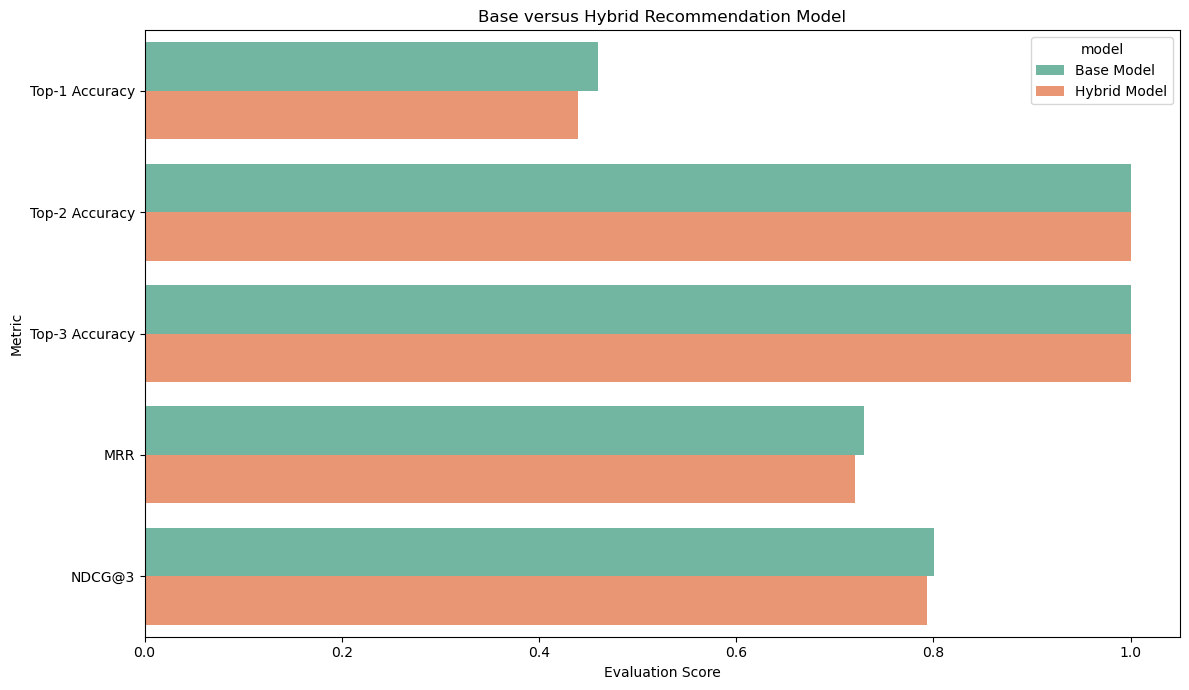

In [17]:
plot_data = model_comparison[
    model_comparison["metric"] !=
    "Mean Target Rank"
].melt(
    id_vars="metric",
    var_name="model",
    value_name="score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_data,
    x="score",
    y="metric",
    hue="model",
    palette="Set2"
)

plt.title("Base versus Hybrid Recommendation Model")
plt.xlabel("Evaluation Score")
plt.ylabel("Metric")

plt.tight_layout()
plt.show()

In [18]:
recommendation_distribution = (
    ranking_results["rank_1_class"]
    .value_counts()
    .reset_index()
)

recommendation_distribution.columns = [
    "recommended_class",
    "recommendation_count"
]

recommendation_distribution

,recommended_class,recommendation_count
0,Antihypertensive class B,12
1,Controller inhaler class,9
2,Lipid-lowering class A,9
3,Antidiabetic class B,9
4,Antihistamine class A,9
5,Antihistamine class B,9
6,Acid-suppression class B,8
7,Bronchodilator class,8
8,Antidiabetic class A,8
9,Acid-suppression class A,7


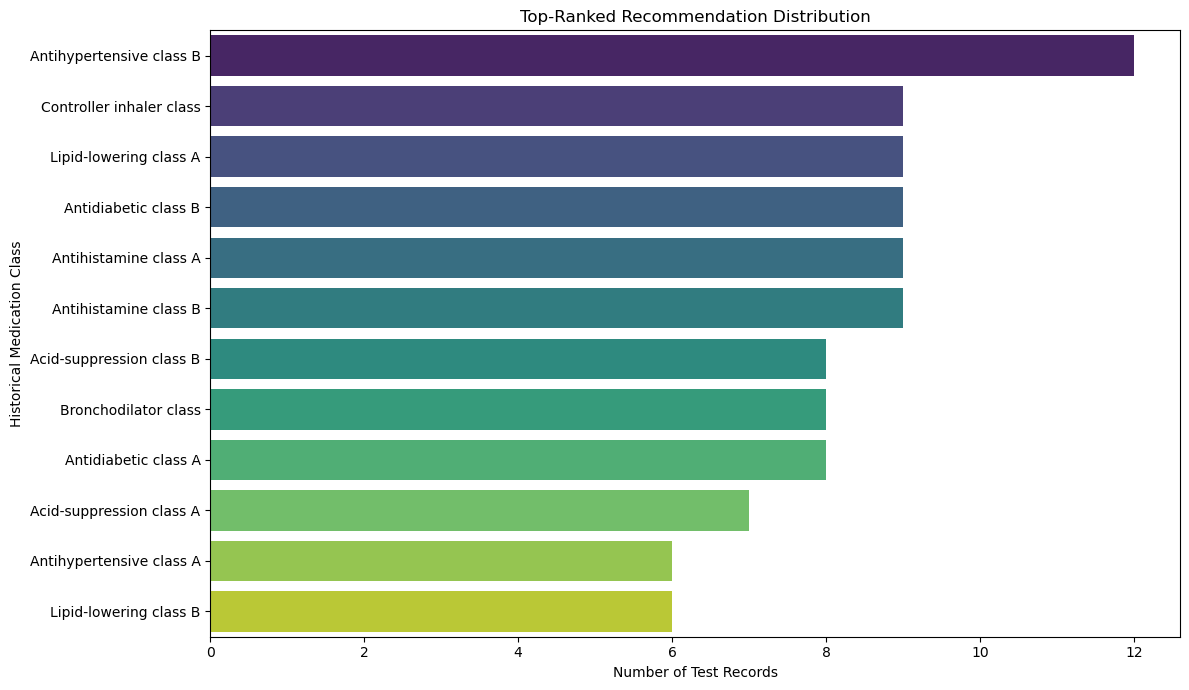

In [19]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=recommendation_distribution,
    x="recommendation_count",
    y="recommended_class",
    hue="recommended_class",
    palette="viridis",
    legend=False
)

plt.title("Top-Ranked Recommendation Distribution")
plt.xlabel("Number of Test Records")
plt.ylabel("Historical Medication Class")

plt.tight_layout()
plt.show()

In [20]:
condition_evaluation = (
    ranking_results
    .groupby("condition")
    .agg(
        patient_count=("patient_id", "count"),
        top_1_accuracy=("top_1_correct", "mean"),
        top_2_accuracy=("top_2_correct", "mean"),
        top_3_accuracy=("top_3_correct", "mean"),
        mean_target_rank=(
            "actual_class_rank",
            "mean"
        )
    )
    .reset_index()
)

condition_evaluation[
    [
        "top_1_accuracy",
        "top_2_accuracy",
        "top_3_accuracy",
        "mean_target_rank"
    ]
] = condition_evaluation[
    [
        "top_1_accuracy",
        "top_2_accuracy",
        "top_3_accuracy",
        "mean_target_rank"
    ]
].round(4)

condition_evaluation

,condition,patient_count,top_1_accuracy,top_2_accuracy,top_3_accuracy,mean_target_rank
0,Acid Reflux,15,0.5333,1.0,1.0,1.4667
1,Asthma,17,0.5882,1.0,1.0,1.4118
2,High Cholesterol,15,0.2667,1.0,1.0,1.7333
3,Hypertension,18,0.3889,1.0,1.0,1.6111
4,Seasonal Allergy,18,0.3889,1.0,1.0,1.6111
5,Type 2 Diabetes,17,0.4706,1.0,1.0,1.5294


In [21]:
ranking_results[
    "review_status"
] = np.where(
    ranking_results[
        "recorded_allergy"
    ].str.lower().eq("none recorded"),
    "Professional review required",
    "Allergy recorded; safety verification required"
)

ranking_results[
    "educational_notice"
] = (
    "Synthetic historical ranking; not a prescription"
)

ranking_results.head()

,patient_id,condition,recorded_allergy,actual_historical_class,rank_1_class,rank_1_score,rank_2_class,rank_2_score,rank_3_class,rank_3_score,actual_class_rank,top_1_correct,top_2_correct,top_3_correct,review_status,educational_notice
0,SYN-0049,Asthma,None recorded,Controller inhaler class,Controller inhaler class,0.7134,Bronchodilator class,0.2502,Antihistamine class B,0.0085,1,True,True,True,Professional review required,Synthetic historical ranking; not a prescription
1,SYN-0135,Type 2 Diabetes,None recorded,Antidiabetic class A,Antidiabetic class B,0.5832,Antidiabetic class A,0.4110,Bronchodilator class,0.0015,2,False,True,True,Professional review required,Synthetic historical ranking; not a prescription
2,SYN-0094,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5792,Lipid-lowering class B,0.4040,Antihypertensive class A,0.0043,1,True,True,True,Professional review required,Synthetic historical ranking; not a prescription
3,SYN-0131,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5383,Lipid-lowering class B,0.4519,Antihistamine class B,0.0021,1,True,True,True,Professional review required,Synthetic historical ranking; not a prescription
4,SYN-0467,Seasonal Allergy,None recorded,Antihistamine class B,Antihistamine class A,0.5194,Antihistamine class B,0.3572,Lipid-lowering class A,0.0326,2,False,True,True,Professional review required,Synthetic historical ranking; not a prescription


In [22]:
output_file = "recommendation_ranking_evaluation.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    ranking_results.to_excel(
        writer,
        sheet_name="Ranked_Recommendations",
        index=False
    )

    ranking_metrics.to_excel(
        writer,
        sheet_name="Ranking_Metrics",
        index=False
    )

    classification_metrics.to_excel(
        writer,
        sheet_name="Classification_Metrics",
        index=False
    )

    model_comparison.to_excel(
        writer,
        sheet_name="Model_Comparison",
        index=False
    )

    condition_evaluation.to_excel(
        writer,
        sheet_name="Condition_Evaluation",
        index=False
    )

    recommendation_distribution.to_excel(
        writer,
        sheet_name="Recommendation_Counts",
        index=False
    )

    coverage_results.to_excel(
        writer,
        sheet_name="Coverage",
        index=False
    )

print("Ranking evaluation completed.")
print("Saved:", output_file)

Ranking evaluation completed.
Saved: recommendation_ranking_evaluation.xlsx
